<a href="https://colab.research.google.com/github/shahodi011/IT326-Project/blob/main/Reports/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1

# Project Goal

The goal of this project is to apply data mining techniques to classify patients by Alzheimer’s disease stage ,We aim to use clustering to group patients with similar traits and uncover hidden patterns.

# Dataset Source
The dataset was obtained from Kaggle:  
[Alzheimer’s Disease Dataset](https://www.kaggle.com/datasets/rabieelkharoua/alzheimers-disease-dataset)  

# Dataset Description

to retrieve the dataset info, we need to import it as follows :


In [16]:
import pandas as pd
df = pd.read_csv("Raw_dataset.csv")
ID_COLS = ["PatentID"]



Now we can easily obtain the dataset info

Number and data types of attributes :

In [17]:
attribute_info = pd.DataFrame({
    'NameOfAttribute' : df.columns,
    'DataType' : df.dtypes.values
})
print(f"Attributes with their data types: \n")
print(attribute_info, "\n")

print("Number of attributes:", len(df.columns), "\n")

Attributes with their data types: 

              NameOfAttribute DataType
0                   PatientID    int64
1                         Age    int64
2                      Gender    int64
3                   Ethnicity    int64
4              EducationLevel    int64
5                         BMI  float64
6                     Smoking    int64
7          AlcoholConsumption  float64
8            PhysicalActivity  float64
9                 DietQuality  float64
10               SleepQuality  float64
11    FamilyHistoryAlzheimers    int64
12      CardiovascularDisease    int64
13                   Diabetes    int64
14                 Depression    int64
15                 HeadInjury    int64
16               Hypertension    int64
17                 SystolicBP    int64
18                DiastolicBP    int64
19           CholesterolTotal  float64
20             CholesterolLDL  float64
21             CholesterolHDL  float64
22   CholesterolTriglycerides  float64
23                       MMS

Number of objects :

In [18]:
print("Number of objects: ", len(df),"\n")

Number of objects:  2149 



Class attribute information

In [19]:
class_col = "Diagnosis"
print("Class attribute name: ", class_col, "\n")

Class attribute name:  Diagnosis 



Show all unique values (labels)

In [20]:
print("Possible values in the class attribute:",df[class_col].unique(), "\n")

Possible values in the class attribute: [0 1] 



Show counts for each class

In [21]:
print("Counts for each class in",df[class_col].value_counts())
print("")

Counts for each class in Diagnosis
0    1389
1     760
Name: count, dtype: int64



Sample of the raw dataset

In [22]:
print("Sample of the raw dataset:")
print(df.head())

Sample of the raw dataset:
   PatientID  Age  Gender  Ethnicity  EducationLevel        BMI  Smoking  \
0       4751   73       0          0               2  22.927749        0   
1       4752   89       0          0               0  26.827681        0   
2       4753   73       0          3               1  17.795882        0   
3       4754   74       1          0               1  33.800817        1   
4       4755   89       0          0               0  20.716974        0   

   AlcoholConsumption  PhysicalActivity  DietQuality  ...  MemoryComplaints  \
0           13.297218          6.327112     1.347214  ...                 0   
1            4.542524          7.619885     0.518767  ...                 0   
2           19.555085          7.844988     1.826335  ...                 0   
3           12.209266          8.428001     7.435604  ...                 0   
4           18.454356          6.310461     0.795498  ...                 0   

   BehavioralProblems       ADL  Confusio

#  Phase 2

# Part 1 :Data Summarization

##1. Descriptive Statistics (Five-number Summary)
We report the five-number summary for numeric attributes: minimum, 25% (Q1), 50% (median,Q2), 75% (Q3), and maximum.

In [23]:
df.describe()

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
count,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,...,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000,2149.000000
mean,5825.000000,74.908795,0.506282,0.697534,1.286645,27.655697,0.288506,10.039442,4.920202,4.993138,...,5.080055,0.208004,0.156817,4.982958,0.205212,0.158213,0.150768,0.158678,0.301536,0.353653
std,620.507185,8.990221,0.500077,0.996128,0.904527,7.217438,0.453173,5.757910,2.857191,2.909055,...,2.892743,0.405974,0.363713,2.949775,0.403950,0.365026,0.357906,0.365461,0.459032,0.478214
min,4751.000000,60.000000,0.000000,0.000000,0.000000,15.008851,0.000000,0.002003,0.003616,0.009385,...,0.000460,0.000000,0.000000,0.001288,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5288.000000,67.000000,0.000000,0.000000,1.000000,21.611408,0.000000,5.139810,2.570626,2.458455,...,2.566281,0.000000,0.000000,2.342836,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5825.000000,75.000000,1.000000,0.000000,1.000000,27.823924,0.000000,9.934412,4.766424,5.076087,...,5.094439,0.000000,0.000000,5.038973,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,6362.000000,83.000000,1.000000,1.000000,2.000000,33.869778,1.000000,15.157931,7.427899,7.558625,...,7.546981,0.000000,0.000000,7.581490,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
max,6899.000000,90.000000,1.000000,3.000000,3.000000,39.992767,1.000000,19.989293,9.987429,9.998346,...,9.996467,1.000000,1.000000,9.999747,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## 2.Missing Values
We show the number of missing values per column. Columns with missing values will be handled during preprocessing.

In [24]:
df.isnull().sum()

,0
PatientID,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0


##3. Class Label Distribution
We use Diagnosis as the class label. The counts below show the class distribution to consider later in modeling.


In [25]:
TARGET_COL = "Diagnosis"
df[TARGET_COL].value_counts()

,count
Diagnosis,
0,1389
1,760


##4. Graphs

4.1 Histogram

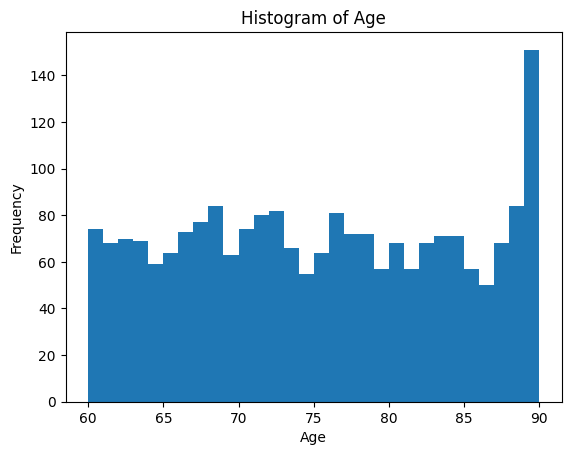

In [34]:

df["Age"].plot(kind="hist", bins=30, title="Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()


Describtion: The distribution shows that most patients are in older age groups, especially between their 60s and 80s. This matches the expectation that Alzheimer’s mainly affects elderly people.

4.2 Box Plot

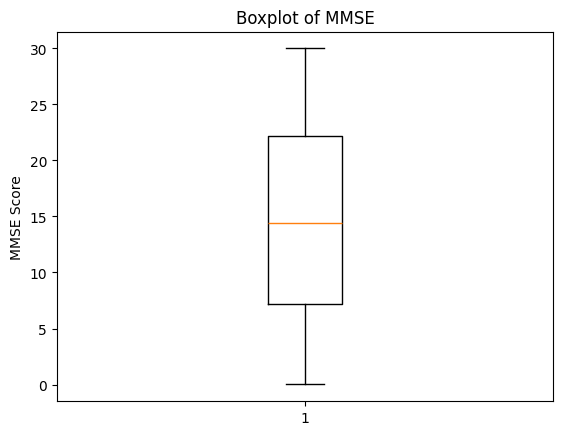

In [27]:

plt.boxplot(df["MMSE"].dropna())
plt.title("Boxplot of MMSE")
plt.ylabel("MMSE Score")
plt.show()


Describtion: The boxplot shows that most patients fall within a healthy-to-borderline cholesterol range, while outliers represent very high levels. This is important because elevated cholesterol is a known risk factor for Alzheimer’s, making this attribute valuable for analysis.


4.3 Bar Plot

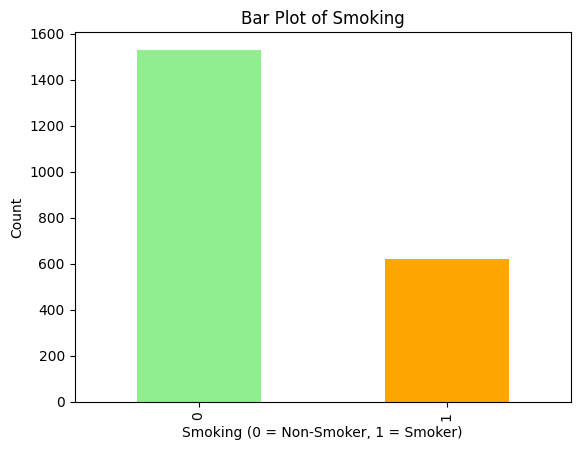

In [28]:
df["Smoking"].value_counts().plot(
    kind="bar",
    title="Bar Plot of Smoking",
    color=["lightgreen", "orange"]
)
plt.xlabel("Smoking (0 = Non-Smoker, 1 = Smoker)")
plt.ylabel("Count")
plt.show()


Describtion: The bar plot shows that most patients in the dataset are non-smokers, while a smaller portion are smokers. This imbalance may influence how lifestyle factors connect to Alzheimer’s risk.

4.4 Class Label Distribution

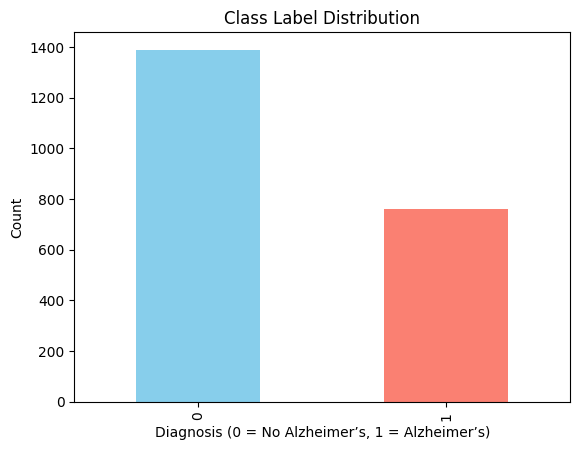

In [29]:
df["Diagnosis"].value_counts().plot(
    kind="bar",
    title="Class Label Distribution",
    color=["skyblue", "salmon"]
)
plt.xlabel("Diagnosis (0 = No Alzheimer’s, 1 = Alzheimer’s)")
plt.ylabel("Count")
plt.show()



Describtion: The bar plot shows how the dataset is split between the two diagnosis classes. Patients labeled 0 (no Alzheimer’s) are more frequent than those labeled 1 (Alzheimer’s). This imbalance is important to notice because it can affect classification results later.

# Part 2 :Data Preprocessing

# Imputation

In [30]:
from sklearn.impute import SimpleImputer



df_imp = df.copy()

num_cols = df_imp.select_dtypes(include=["int64","float64"]).columns.tolist()
cat_cols = df_imp.select_dtypes(exclude=["int64","float64"]).columns.tolist()


if "Diagnosis" in num_cols:
    num_cols.remove("Diagnosis")

num_imputer = SimpleImputer(strategy="median")
cat_imputer = SimpleImputer(strategy="most_frequent")

if num_cols:
    df_imp[num_cols] = num_imputer.fit_transform(df_imp[num_cols])
if cat_cols:
    df_imp[cat_cols] = cat_imputer.fit_transform(df_imp[cat_cols])

print("After imputation — any nulls?")
display(df_imp.isnull().sum().sort_values(ascending=False).head(10))
display(df_imp.head())


After imputation — any nulls?


,0
PatientID,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751.0,73.0,0.0,0.0,2.0,22.927749,0.0,13.297218,6.327112,1.347214,...,0.0,0.0,1.725883,0.0,0.0,0.0,1.0,0.0,0,XXXConfid
1,4752.0,89.0,0.0,0.0,0.0,26.827681,0.0,4.542524,7.619885,0.518767,...,0.0,0.0,2.592424,0.0,0.0,0.0,0.0,1.0,0,XXXConfid
2,4753.0,73.0,0.0,3.0,1.0,17.795882,0.0,19.555085,7.844988,1.826335,...,0.0,0.0,7.119548,0.0,1.0,0.0,1.0,0.0,0,XXXConfid
3,4754.0,74.0,1.0,0.0,1.0,33.800817,1.0,12.209266,8.428001,7.435604,...,0.0,1.0,6.481226,0.0,0.0,0.0,0.0,0.0,0,XXXConfid
4,4755.0,89.0,0.0,0.0,0.0,20.716974,0.0,18.454356,6.310461,0.795498,...,0.0,0.0,0.014691,0.0,0.0,1.0,1.0,0.0,0,XXXConfid


### 1)Normalization

We discretized the Age attribute into four groups: <60, 60–69, 70–79, and 80+.  
This was chosen because Alzheimer’s is strongly related to age,  
and grouping values makes patterns clearer.  
The result is a new column "AgeGroup" that reduces noise  
and improves interpretability.

In [31]:
from sklearn.impute import SimpleImputer

TARGET="Diagnosis"

df_imp = df.copy()

num_cols = df_imp.select_dtypes(include=['number']).columns.tolist()
cat_cols = df_imp.select_dtypes(exclude=['number']).columns.tolist()

if TARGET in num_cols:
    num_cols.remove(TARGET)
if TARGET in cat_cols:
    cat_cols.remove(TARGET)

if num_cols:
    num_imputer = SimpleImputer(strategy='median')
    df_imp[num_cols] = num_imputer.fit_transform(df_imp[num_cols])

if cat_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df_imp[cat_cols] = cat_imputer.fit_transform(df_imp[cat_cols])

print("After imputation — any nulls?")
display(df_imp.isnull().sum().sort_values(ascending=False).head(10))
display(df_imp.head())


After imputation — any nulls?


,0
PatientID,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751.0,73.0,0.0,0.0,2.0,22.927749,0.0,13.297218,6.327112,1.347214,...,0.0,0.0,1.725883,0.0,0.0,0.0,1.0,0.0,0,XXXConfid
1,4752.0,89.0,0.0,0.0,0.0,26.827681,0.0,4.542524,7.619885,0.518767,...,0.0,0.0,2.592424,0.0,0.0,0.0,0.0,1.0,0,XXXConfid
2,4753.0,73.0,0.0,3.0,1.0,17.795882,0.0,19.555085,7.844988,1.826335,...,0.0,0.0,7.119548,0.0,1.0,0.0,1.0,0.0,0,XXXConfid
3,4754.0,74.0,1.0,0.0,1.0,33.800817,1.0,12.209266,8.428001,7.435604,...,0.0,1.0,6.481226,0.0,0.0,0.0,0.0,0.0,0,XXXConfid
4,4755.0,89.0,0.0,0.0,0.0,20.716974,0.0,18.454356,6.310461,0.795498,...,0.0,0.0,0.014691,0.0,0.0,1.0,1.0,0.0,0,XXXConfid


After normalization, all numeric attributes are balanced and contribute equally during training.

### 2)Discretization

The Age attribute was transformed into categorical groups: <60, 60–69, 70–79, and 80+. This makes the relationship between Age and Diagnosis easier to understand, since Alzheimer’s is strongly age-related.

In [32]:
import numpy as np

df_disc = df.copy()

if "Age" in df_disc.columns:
    bins   = [0, 59, 69, 79, np.inf]
    labels = ["<60","60-69","70-79","80+"]
    df_disc["AgeGroup"] = pd.cut(df_disc["Age"], bins=bins, labels=labels, right=True)
    print("AgeGroup distribution:")
    display(df_disc["AgeGroup"].value_counts(dropna=False))
    display(df_disc[["Age","AgeGroup"]].head())
else:
    print("Column 'Age' not found — skip Discretization step or choose another continuous feature.")


AgeGroup distribution:


,count
AgeGroup,
80+,745
70-79,703
60-69,701
<60,0


,Age,AgeGroup
0,73,70-79
1,89,80+
2,73,70-79
3,74,70-79
4,89,80+


Converting continuous values into groups reduces noise and highlights clear patterns across age intervals

### 3)Feature Selection

We used SelectKBest with the ANOVA F-test to select the most relevant features correlated with the Diagnosis column. This allowed us to remove less useful attributes, reduce dimensionality, and focus only on the most informative predictors.

In [33]:
from pandas.api.types import is_numeric_dtype
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold

X = df_disc.drop(columns=["PatientID", "Diagnosis"], errors="ignore").copy()
y = df_disc["Diagnosis"].copy()

for col in X.columns:
    if is_numeric_dtype(X[col]):
        if X[col].isna().any():
            X[col] = X[col].fillna(X[col].median())
    else:
        if X[col].isna().any():
            mode_val = X[col].mode(dropna=True)
            X[col] = X[col].fillna(mode_val.iloc[0] if not mode_val.empty else "UNK")
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))

if not is_numeric_dtype(y):
    le_y = LabelEncoder()
    y = le_y.fit_transform(y.astype(str))
else:
    y = y.astype(int)

vt = VarianceThreshold(threshold=0)
vt.fit(X)
X = X.loc[:, vt.get_support()]

k = min(10, X.shape[1])
selector = SelectKBest(score_func=f_classif, k=k)
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()].tolist()

print(f"Selected features (k={k}): {selected_features}")


Selected features (k=10): ['EducationLevel', 'SleepQuality', 'FamilyHistoryAlzheimers', 'Hypertension', 'CholesterolHDL', 'MMSE', 'FunctionalAssessment', 'MemoryComplaints', 'BehavioralProblems', 'ADL']


As a result, the dataset became more compact, less noisy, and more efficient for the upcoming data mining tasks.